In [2]:
import numpy as np
from scipy.optimize import curve_fit
from astropy.io import fits
import matplotlib.pyplot as plt
import os
from itertools import product
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pandas as pd
from functools import partial

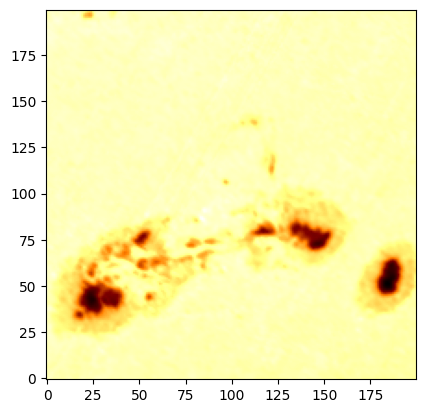

In [ ]:
image_datas=image_data[680:880,1400:1600]
plt.imshow(image_datas,cmap='afmhot',origin='lower')
#参考区域

__<font color=cyan>云模型公式（单一速度）</font>__  
$\tau(\lambda) = \tau_0 \exp\left(-\frac{(\lambda-\mu)^2}{2\Delta \lambda^2}\right)$  
$I(\lambda) = I_0(\lambda) \exp(-\tau(\lambda)) + S(1-\exp(-\tau(\lambda)))$  

In [52]:
def model_spectrum(lam, tau0, delta_lambda, S, mu,I_0,left_index,right_index):
    I_0=I_0[left_index:right_index]
    tau_lam = tau0 * np.exp(-0.5*((lam-mu)**2) / delta_lambda**2)
    return I_0* np.exp(-tau_lam) + S * (1 - np.exp(-tau_lam))


[ 2.83899636e+00  1.55709279e-01  2.83064529e+02 -7.17774241e-02]
Doppler velocity:-3.28km/s


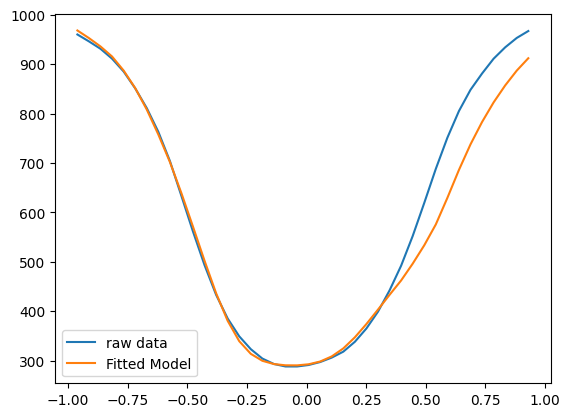

In [53]:
left_index=50
right_index=90
I_0=rsm[1].data[:,705:730,1500:1525].mean(axis=(1,2))
single_cloud=partial(model_spectrum,I_0=I_0,left_index=left_index,right_index=right_index)

initial_tau0=5
initial_delta_lambda=0.5
initial_S=100
initial_mu=0.5

popt,pcov=curve_fit(single_cloud,lam[left_index:right_index],rsm[1].data[left_index:right_index,1521,795],
                    p0=[initial_tau0, initial_delta_lambda, initial_S,initial_mu],
                    bounds = ([0.3,0.1, 0.001,-2],[10,1.2,500,2]),
                    maxfev = 2000)

tau0_fit,delta_lambda_fit,S_fit,mu_fit=popt
print(popt)
doppler_vel=mu_fit/6562.8*299792.458
print(f"Doppler velocity:{doppler_vel:.2f}km/s")

y_fit=model_spectrum(lam[left_index:right_index],tau0_fit,
                     delta_lambda_fit,S_fit,mu_fit,I_0,left_index,right_index)
plt.plot(lam[left_index:right_index],rsm[1].data[left_index:right_index,1521,795],label='raw data')
plt.plot(lam[left_index:right_index],y_fit,label='Fitted Model')
plt.legend()

__<font color=cyan>云模型公式（一蓝一红双速度）</font>__  
$\tau_1(\lambda)=\tau_{01} \exp\left(-\frac{(\lambda-\mu_1)^2}{2\Delta \lambda_1^2}\right)$  
$\tau_2(\lambda)=\tau_{02} \exp\left(-\frac{(\lambda-\mu_2)^2}{2\Delta \lambda_2^2}\right)$  
$I=I_0(\lambda) (e^{-\tau_1(\lambda)}+e^{-\tau_2(\lambda)})+S_1(1-e^{-\tau_1(\lambda)})+S_2(1-e^{-\tau_2(\lambda)})$  

In [4]:
def double_vel(lam,tau01,tau02,mu1,mu2,delta_lambda1,delta_lambda2,
               S1,S2,I0,left_index,right_index):
    I0=I0[left_index:right_index]
    lam=lam[left_index:right_index]
    tau1_lam=tau01*np.exp(-0.5*((lam-mu1)**2)/delta_lambda1**2)
    tau2_lam=tau02*np.exp(-0.5*((lam-mu2)**2)/delta_lambda2**2)
    I=I0*(np.exp(-tau1_lam)+np.exp(-tau2_lam))+S1*(1-np.exp(-tau1_lam))+S2*(1-np.exp(-tau2_lam))
    return I

tau01:20.00 tau02:0.46 mu1:-0.85 mu2:1.50
delta_lambda1:0.90 delta_lambda2:1.54 S1:57.74 S2:0.00
vel1:-38.66km/s vel2:68.57km/s


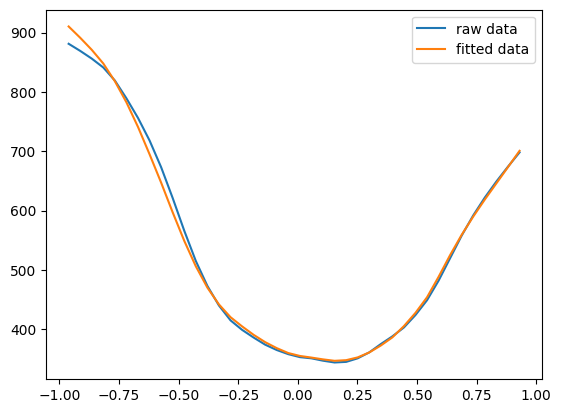

In [49]:
I0=rsm[1].data[:,705:730,1500:1525].mean(axis=(1,2))
left_index=50
right_index=90
double_vel_cloud=partial(double_vel,I0=I0,
                         left_index=left_index,right_index=right_index)

#设置初始参数
paras=np.zeros(24)
#0-2是tau01_initial,min,max
paras[0],paras[1],paras[2]=5,0.3,20
#3-5是tau02_initial,min,max
paras[3],paras[4],paras[5]=5,0.3,20
#6-8是mu1_initial,min,max
paras[6],paras[7],paras[8]=-0.15,-1.5,0
#9-11是mu2_initial,min,max
paras[9],paras[10],paras[11]=0.15,0,1.5
#12-14是delta_lambda1_initial,min,max
paras[12],paras[13],paras[14]=0.5,0.1,2                      
#15-17是delta_lambda2_initial,min,max
paras[15],paras[16],paras[17]=0.5,0.1,2
#18-20是S1_initial,min,max
paras[18],paras[19],paras[20]=50,0.0,100
#21-23是S2_initial,min,max
paras[21],paras[22],paras[23]=50,0.0,100

#曲线拟合
popt,pcov=curve_fit(double_vel_cloud,lam,
                    rsm[1].data[left_index:right_index,795,1521],
                    p0=paras[0::3],bounds=(paras[1::3],paras[2::3]),
                    maxfev=2000)
tau01_fit=popt[0]
tau02_fit=popt[1]
mu1_fit=popt[2]
mu2_fit=popt[3]
delta_lambda1_fit=popt[4]
delta_lambda2_fit=popt[5]
S1_fit=popt[6]
S2_fit=popt[7]
print(f"tau01:{tau01_fit:.2f} tau02:{tau02_fit:.2f} mu1:{mu1_fit:.2f} mu2:{mu2_fit:.2f}")
print(f"delta_lambda1:{delta_lambda1_fit:.2f} delta_lambda2:{delta_lambda2_fit:.2f} S1:{S1_fit:.2f} S2:{S2_fit:.2f}")
vel1=mu1_fit/6562.8*3e5
vel2=mu2_fit/6562.8*3e5
print(f"vel1:{vel1:.2f}km/s vel2:{vel2:.2f}km/s")

plt.plot(lam[left_index:right_index],rsm[1].data[left_index:right_index,795,1521],label='raw data')
plt.plot(lam[left_index:right_index],double_vel_cloud(lam,*popt),label='fitted data')
plt.legend()

In [50]:
lam=lam+6562.8